# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on an integrated RF transformer, extracting the broadband S-parameters to evaluate differential performance metrics such as insertion loss and impedance matching.

**Requirements:**
- IHP PDK: `uv pip install ihp-gdsfactory`
- gsim with Palace backend

In [1]:
import math

import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.typings import LayerSpec, LayerSpecs
from ihp import PDK

PDK.activate()

### Build transformer

In [2]:
def secondary_inductor(
    width: float = 3.0,
    space: float = 3.1,
    diameter: float = 50.0,
    layer_metal: LayerSpec = "TopMetal2drawing",
    layer_metal_name: str = "TopMetal2",
    layer_jumper: LayerSpec = "TopMetal1drawing",
    layer_jumper_name: str = "TopMetal1",
    via_size: float = 1.5,
) -> Component:
    w = width
    s = space
    d = diameter

    r = d / 2 + s
    octagon_center_y = 3 * r
    pi_over_4 = math.radians(45)

    path_points = [(+space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2))]
    for i in range(-2, 6):
        angle = i * pi_over_4 + pi_over_4 / 2
        r = d / 2 + s
        x = r * math.cos(angle)
        y = r * math.sin(angle) + octagon_center_y
        path_points.append((x, y))
    path_points.append((-space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2)))

    gap_y = octagon_center_y - r * math.cos(pi_over_4 / 2)

    path = gf.Path(path_points)
    c = gf.path.extrude(path, layer=layer_metal, width=w)

    length = 2 * r + s

    lead1 = c << gf.components.rectangle(size=(s, length), layer=layer_jumper)
    lead1.move((-s - s / 2, 0))
    c.add_port(name="P1", center=(-s, s), width=s, orientation=270, layer=layer_jumper)

    lead2 = c << gf.components.rectangle(size=(s, length), layer=layer_jumper)
    lead2.move((s - s / 2, 0))
    c.add_port(name="P2", center=(s, s), width=s, orientation=270, layer=layer_jumper)

    via_stack_component = gf.get_component(
        "via_stack",
        bottom_layer=layer_jumper_name,
        top_layer=layer_metal_name,
        size=(via_size, via_size),
        vn_columns=1,
        vn_rows=1,
    )
    junction1 = c.add_ref(via_stack_component)
    junction1.move(junction1.center, (-space, gap_y))
    junction2 = c.add_ref(via_stack_component)
    junction2.move(junction2.center, (space, gap_y))

    c.flatten()
    return c

In [3]:
@gf.cell
def transformer_concentric(
    width_primary: float = 3.0,
    width_secondary: float = 3.0,
    space: float = 3.1,
    coupling_gap: float = 4.0,
    diameter_outer: float = 80.0,
    layer: LayerSpec = "TopMetal2drawing",
    layer_name: str = "TopMetal2",
    jumper_layer: LayerSpec = "TopMetal1drawing",
    jumper_bottom_layer_name: str = "TopMetal1",
    via_size: float | None = None,
    layer_inductor: LayerSpec = "INDdrawing",
    layers_no_fill: LayerSpecs = ("NoMetFillerdrawing",),
) -> Component:
    """Concentric, coplanar 1:1 transformer (single-turn coils).

    Primary: standard gf.components.inductor(), outer ring, on `layer`.
    Secondary: same octagonal spiral, inner ring, but its leads are drawn
    on `jumper_layer` (TopMetal1) instead of `layer`, so they pass
    underneath the primary ring without colliding. A via_stack connects
    each lead to the coil body right where they meet, then the lead runs
    on jumper_layer straight out past the primary's outer edge.

    Returns:
        Component with ports P1, P2 (primary, on layer) and
        S1, S2 (secondary, on jumper_layer).
    """
    c = gf.Component()
    via_size = via_size or width_secondary

    # Primary coil (outer ring), standard inductor
    primary = gf.components.inductor(
        width=width_primary,
        space=space,
        diameter=diameter_outer,
        turns=1,
        layer_metal=layer,
        layer_inductor=layer_inductor,
        layer_metal_pin=layer,
        layers_no_fill=layers_no_fill,
    )
    prim_ref = c.add_ref(primary)
    cx, cy = prim_ref.center
    prim_ref.move((-cx, -cy))

    # Compute inner diameter for secondary
    diameter_secondary = diameter_outer - 2 * (width_primary + space) - 2 * coupling_gap

    # Secondary coil geometry
    w = width_secondary
    s = space
    d = diameter_secondary

    r = d / 2 + s
    octagon_center_y = 3 * r
    pi_over_4 = math.radians(45)

    path_points = [(+space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2))]
    for i in range(-2, 6):
        angle = i * pi_over_4 + pi_over_4 / 2
        r = d / 2 + s
        x = r * math.cos(angle)
        y = r * math.sin(angle) + octagon_center_y
        path_points.append((x, y))
    path_points.append((-space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2)))

    # This is the actual gap where the coil is open — the real
    # junction point between the coil body and each lead
    gap_y = octagon_center_y - r * math.cos(pi_over_4 / 2)

    path = gf.Path(path_points)
    secondary = gf.path.extrude(path, layer=layer, width=w)

    length = 2 * r + s

    lead1 = secondary << gf.components.rectangle(size=(s, length), layer=jumper_layer)
    lead1.move((-s - s / 2, 0))
    lead2 = secondary << gf.components.rectangle(size=(s, length), layer=jumper_layer)
    lead2.move((s - s / 2, 0))

    # Connect coil body (layer) to each lead (jumper_layer)
    via_stack_component = gf.get_component(
        "via_stack",
        bottom_layer=jumper_bottom_layer_name,
        top_layer=layer_name,
        size=(via_size, via_size),
    )
    junction1 = secondary.add_ref(via_stack_component)
    junction1.move(junction1.center, (-space, gap_y))
    junction2 = secondary.add_ref(via_stack_component)
    junction2.move(junction2.center, (space, gap_y))

    # External ports on jumper_layer
    secondary.add_port(
        name="S1", center=(-s, s), width=s, orientation=90, layer=jumper_layer
    )
    secondary.add_port(
        name="S2", center=(s, s), width=s, orientation=90, layer=jumper_layer
    )

    # IND marker layer
    outer_polygon_pts = []
    for i in range(8):
        r_outer = (d / 2 + length) / (math.cos(pi_over_4 / 2))
        angle = i * pi_over_4 + pi_over_4 / 2
        x = r_outer * math.cos(angle)
        y = r_outer * math.sin(angle) + octagon_center_y
        outer_polygon_pts.append((x, y))
    secondary.add_polygon(points=outer_polygon_pts, layer=layer_inductor)

    sec_ref = c.add_ref(secondary)
    sec_ref.rotate(180)
    cx, cy = sec_ref.center
    sec_ref.move((-cx, -cy))

    # Expose all 4 ports
    c.add_port(name="P1", port=prim_ref.ports["P1"])
    c.add_port(name="P2", port=prim_ref.ports["P2"])
    c.add_port(name="S1", port=sec_ref.ports["S1"])
    c.add_port(name="S2", port=sec_ref.ports["S2"])

    c.flatten()
    return c

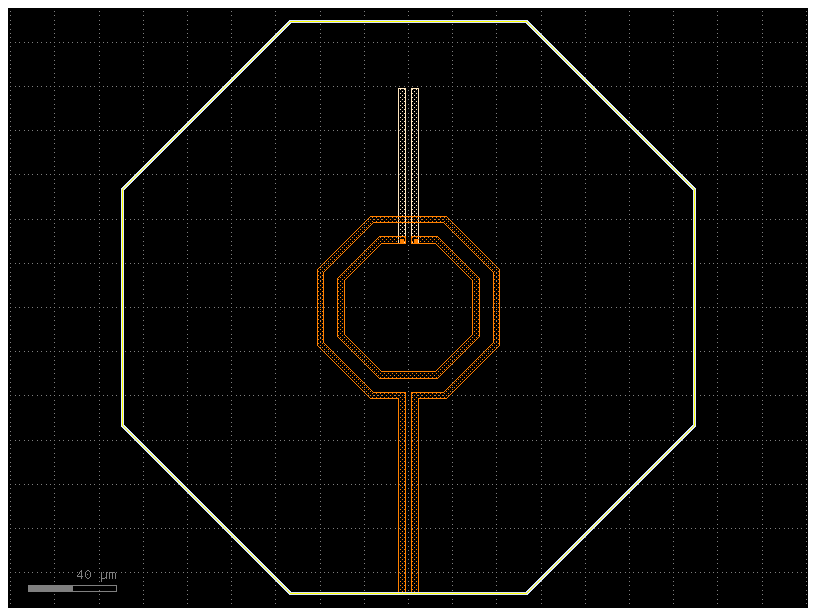

In [4]:
c = transformer_concentric()
c.plot()

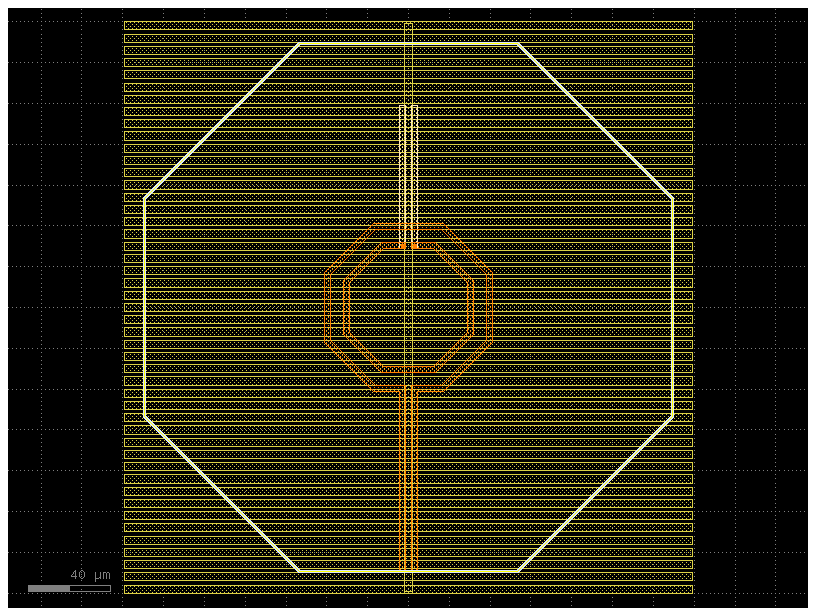

In [5]:
def add_pgs_to_transformer(
    c: gf.Component,
    margin: float = 5.0,
    w: float = 2.0,
    s: float = 2.0,
    layer="Metal5drawing",
):
    bbox = c.bbox()

    # Calculate center manually
    cx = (bbox.left + bbox.right) / 2
    cy = (bbox.bottom + bbox.top) / 2

    # Shield boundaries (Padded)
    xmin, xmax = bbox.left - margin, bbox.right + margin
    ymin, ymax = bbox.bottom - margin, bbox.top + margin

    # 1. Central vertical spine
    c.add_polygon(
        [
            (-w / 2 + cx, ymin),
            (-w / 2 + cx, ymax),
            (w / 2 + cx, ymax),
            (w / 2 + cx, ymin),
        ],
        layer=layer,
    )

    # 2. Horizontal fingers
    pitch = w + s
    total_height = ymax - ymin
    num_fingers = math.floor(total_height / pitch)

    for i in range(-num_fingers // 2, num_fingers // 2 + 1):
        yc = cy + (i * pitch)
        c.add_polygon(
            [
                (xmin, yc - w / 2),
                (xmin, yc + w / 2),
                (xmax, yc + w / 2),
                (xmax, yc - w / 2),
            ],
            layer=layer,
        )


cc = c.copy()
add_pgs_to_transformer(cc, margin=10.0, w=4.0, s=2.0)

cc.plot()

### Configure and run simulation with DrivenSim

In [6]:
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-transformer-concentric")
sim.set_geometry(cc)
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# P1, P2 -> primary coil, on TopMetal2
sim.add_port(
    "P1", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)
sim.add_port(
    "P2", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)

# S1, S" -> secondary coil, same layer as primary
sim.add_port(
    "S1", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)

sim.add_port(
    "S2", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)

sim.set_driven(fmin=10e9, fmax=100e9, num_points=60)
print(sim.validate_config())

Validation: PASSED


In [7]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=3)
sim.write_config()

Small conductor feature detected (2.000 um) may be under-resolved by refined_mesh_size=5.000 um. Pass auto_size=True to scale the mesh down.


Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            


PosixPath('palace-sim-transformer-concentric/config.json')

In [8]:
sim.plot_mesh(show_groups=["metal", "P", "via"])

Widget(value='<iframe src="http://localhost:43769/index.html?ui=P_0x7e85703afa10_0&reconnect=auto" class="pyvi…

In [9]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "sio2__None", "air__sio2"],
)

Widget(value='<iframe src="http://localhost:43769/index.html?ui=P_0x7e845c4b62d0_1&reconnect=auto" class="pyvi…

### Run simulation on cloud

In [10]:
# Run simulation on GDSFactory+ cloud
results = sim.run()

  palace-36518746  completed  18m 22s
Extracting results.tar.gz...
Downloaded 10 files to /home/delfi/Documents/gsim/nbs/sim-data-palace-36518746


In [11]:
results.plot_interactive()

Port mapping: Port 1: P1, Port 2: P2, Port 3: S1, Port 4: S2


In [12]:
results.plot_interactive(phase=True)

Port mapping: Port 1: P1, Port 2: P2, Port 3: S1, Port 4: S2


### S- and Z-parameters from the Palace simulation

`results` currently holds the raw per-port-pair S-parameters returned by Palace. To compare against the lumped-element model later, we load them into an `skrf.Network`, which gives us the S-parameter matrix at every frequency point and lets us derive the corresponding Z-parameters (`ntwk.z`) directly. These are the **EM-simulated** S/Z-parameters of the actual `gdsfactory` layout.

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf

freq_scale = 1e9
f = results.freq * freq_scale
w = 2 * np.pi * f

ports = results.port_names
n = len(ports)

S = np.zeros((len(f), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

ntwk = rf.Network(f=f, s=S, f_unit="hz")
Z = ntwk.z
Y = ntwk.y

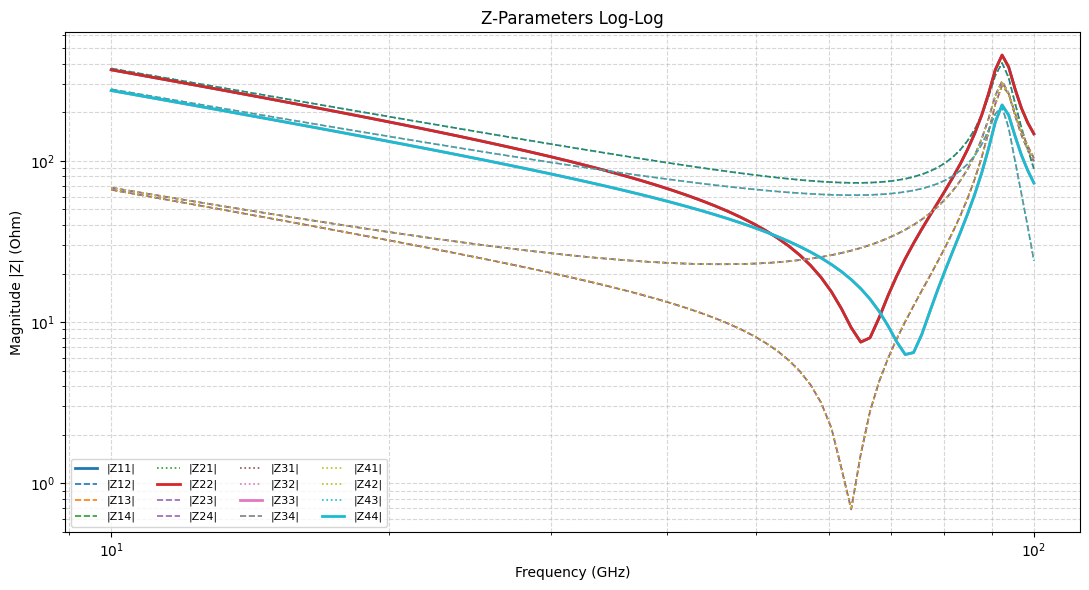

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.cm.tab10
colors = [cmap(k) for k in np.linspace(0, 1, n * n)]

idx = 0
for i in range(n):
    for j in range(n):
        label = f"|Z{i + 1}{j + 1}|"
        ls = "-" if i == j else ("--" if i < j else ":")

        ax.plot(
            f / 1e9,
            np.abs(Z[:, i, j]),
            label=label,
            linestyle=ls,
            linewidth=2 if i == j else 1.2,
            color=colors[idx],
        )
        idx += 1

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Magnitude |Z| (Ohm)")
ax.set_title("Z-Parameters Log-Log")
ax.legend(ncol=n, fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

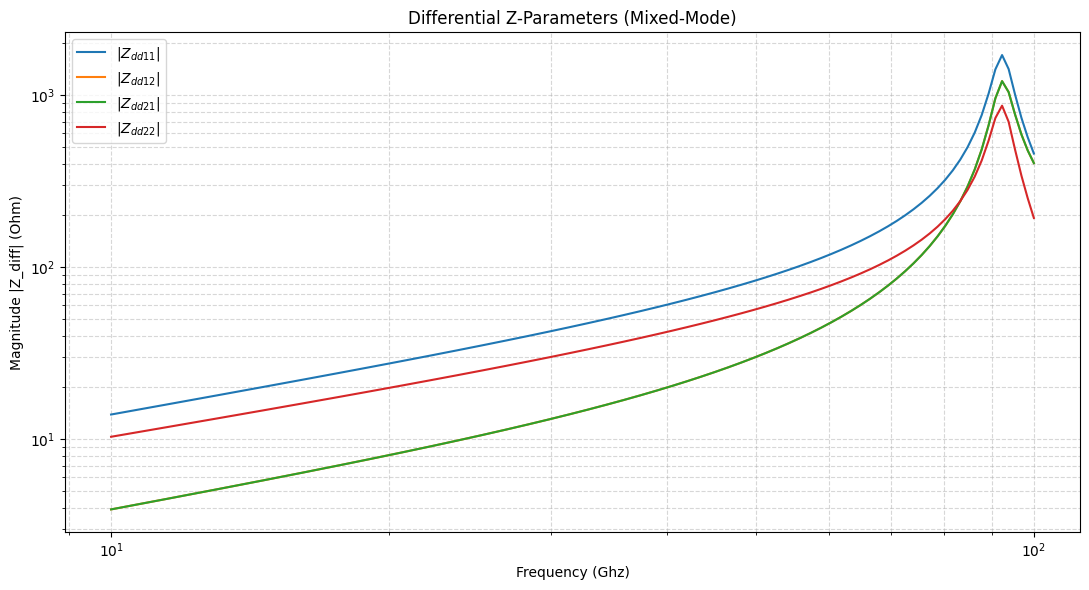

In [28]:
# Get mixed-mode Z-parameters
ntwk_mm = ntwk.copy()
ntwk_mm.se2gmm(p=int(n / 2))
Z_mm = ntwk_mm.z

# Mixed-mode port names are usually:
# 1d (diff), 2d (diff), 1c (common), 2c (common)
labels_mm = [
    "$Z_{dd11}$",
    "$Z_{dd12}$",
    "$Z_{dd21}$",
    "$Z_{dd22}$",
    "$Z_{cc11}$",
    "$Z_{cc12}$",
    "$Z_{cc21}$",
    "$Z_{cc22}$",
]
# Note: The matrix is 4x4, elements of interest can be plotted.

fig, ax = plt.subplots(figsize=(11, 6))

# Plot the main differential terms (DD) if they exist
for i in range(2):
    for j in range(2):
        ax.plot(
            f / 1e9,
            np.abs(Z_mm[:, i, j]),
            label=f"$|Z_{{dd{i + 1}{j + 1}}}|$",
            linestyle="-",
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Frequency (Ghz)")
ax.set_ylabel("Magnitude |Z_diff| (Ohm)")
ax.set_title("Differential Z-Parameters (Mixed-Mode)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

## From EM simulation to a compact circuit model

The Palace simulation above gives accurate broadband S/Z-parameters for the physical `transformer_concentric` layout, but it treats the device as a black box: a full 3-D field solve is needed for every geometry variant, and there is no direct handle on physically meaningful quantities like the primary/secondary self-inductance or the coupling coefficient $\kappa$.

To get that handle, we build a compact lumped-element model of the transformer — self-inductances $L_1, L_2$, mutual inductance $M$, and parasitic series resistance/shunt capacitance — using [`circulax`](https://github.com/), a JAX-based circuit simulator. Once this model reproduces the Palace S/Z-parameters, its parameters *are* the extracted electrical characteristics of the layout, and being written in JAX, the model is differentiable and can later be used to fit those parameters directly against the EM data (or the layout can be optimized against a target circuit response).

The rest of this notebook: (1) defines a `Transformer` component for `circulax`, (2) assembles it into a netlist with the fitted parasitics, and (3) computes its S/Z-parameters the same way as above, so the two can be compared side by side.

### Mutual inductance and coupling constant

To understand inductive coupling, let's recall how inductors work. For simplicity, we shall consider a simple coil in vacuum carrying a current $I$. Then, by Ampere's law, a magnetic field $B \propto I$ is created. Now, if the current changes, field will vary and, according to Faraday's law, an electric field $E \propto dB/dt$ will be generated. The total voltage drop across the terminals of the inductor results from the integration of the electric field along the coil, which can be evaluated using Stokes' Theorem
$$ \Delta V = \int \mathbf{E} \cdot d\mathbf{l} = - \frac{d}{dt}
\iint \mathbf{B} \cdot d\mathbf{S} = - \frac{d\Phi}{dt},$$
where $\Phi$ is called the _magnetic flux_. In a quasistatic case, $\Phi$ will also be proportional to $I$, even in the presence of a magnetic medium as long its magnetization remains linear with the field; the associated proportionality constant is what is called the _inductance_, $L$. Hence, the typical behavior of an inductor in an electric circuit is to create a voltage drop
$$ \Delta V = -L \, \frac{dI}{dt}.$$

It is now possible to extend these definitions to a general case where two (or many) inductors are close to each other, so that the magnetic field created by one coil may contribute to the magnetic flux enclosed by another coil. Let $\Phi_{jk}$ be the magnetic flux at the $j$-th inductor when a current $I_k$ flows through the $k$-th inductor and there are no other currents. Then, by linearity, for an arbitrary combination of currents the total flux will be
$$ \Phi_j = \sum_k \Phi_{jk} = \sum_k L_{jk} I_k,$$
which defines the _mutual inductance_ matrix $\mathbf{L}$.

In particular, $L_{jj}$ is the self inductance of the $j$-th inductor and it can be shown that $L_{jk} = L_{kj}$. Furthermore, every single pair of interacting coils forms its own $2 \times 2$ principal minor $\mathbf{M}^{(jk)}$ within the larger matrix, which will also be symmetric. That guarantees that
$$ 0 \leq \det \mathbf{M}^{(jk)} = L_{jj} L_{kk} - L_{jk}^2 \Rightarrow |L_{jk}| \leq \sqrt{L_{jj} L_{kk}}.$$
Then, we can express off-diagonal terms in terms of the self inductances defining a geometric _coupling constant_
$$\kappa_{jk} = \frac{L_{jk}}{\sqrt{L_{jj} L_{kk}}}, \qquad |\kappa_{jk}| \leq 1.$$

### Non-ideal inductors

Real coils are not made of perfect conductors, so the electric path exhibits a finite ohmic resistance $R_L$. In addition, the proximity between loops or electric lines create a parasitic capacitance $C$. Moreover, electric field variations in the surrounding dielectric medium can produce further losses which can be modeled as an additional resistor $R_C$ in series with $C$.

In [29]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from circulax import compile_circuit, setup_ac_sweep
from circulax.components.electronic import Capacitor, Resistor

# characteristic impedance
Z0 = 50

### A transformer for `circulax`

`circulax` has no built-in `Transformer`, so we define one following the *Writing Components* guide.

A component is a plain function decorated with `@component(ports=..., states=...)`. It receives `signals` (the voltage at each port) and `s` (internal state variables), and returns `(f_dict, q_dict)`:
- **`f_dict`**: instantaneous algebraic constraints — currents that must balance at each port, plus one constraint per state variable.
- **`q_dict`**: state-dependent quantities that the solver differentiates in time (e.g. flux), enforcing `d(q)/dt = f`.

The existing `Inductor` is the template: it stores its current as a state `i_L`, sets the port constraint equal to the voltage drop, and the "storage" term to `-L * i_L` (the flux). The solver then enforces `d(-L*i_L)/dt = v_drop`, i.e. `v_drop = L * di_L/dt`.

A transformer is just two coupled inductors: each coil keeps its own current state, but its flux now depends on **both** currents through the mutual inductance `M`:
$$\phi_1 = L_1 i_{L1} + M i_{L2}, \qquad \phi_2 = M i_{L1} + L_2 i_{L2}.$$


In [30]:
from circulax.components.base_component import Signals, States, component


# primary coil: L1 between p1,p2
# secondary coil: L2 between s1,s2
# with mutual inductance M
@component(ports=("p1", "p2", "s1", "s2"), states=("i_L1", "i_L2"))
def transformer(
    signals: Signals, s: States, L1: float = 1e-9, L2: float = 1e-9, M: float = 0.0
):
    """Two inductively coupled coils: primary (p1, p2), secondary (s1, s2).

    Flux linkage:  phi1 = L1*i_L1 + M*i_L2
                   phi2 = M*i_L1 + L2*i_L2
    so that        V1 = d(phi1)/dt,  V2 = d(phi2)/dt
    """
    v1 = signals.p1 - signals.p2
    v2 = signals.s1 - signals.s2
    f_dict = {
        "p1": s.i_L1,
        "p2": -s.i_L1,
        "s1": s.i_L2,
        "s2": -s.i_L2,
        "i_L1": v1,
        "i_L2": v2,
    }
    q_dict = {
        "i_L1": -(L1 * s.i_L1 + M * s.i_L2),
        "i_L2": -(M * s.i_L1 + L2 * s.i_L2),
    }
    return f_dict, q_dict

### Full model
Now, the parasitic elements can be introduced using the tested transformer component.
As a starting point, the previously fitted parameters of the RLC equivalent model for the single inductor will be used:
- $R_{1,2} = 5\,\Omega$
- $L_{1,2} = 120$ pH
- $C_{1,2} = 7$ fF

and for the loss in the dielectric,
- $R_{3,4} \ll  1/(\omega_0 C) $

so that the parasitic capacitance remains mostly reactive.

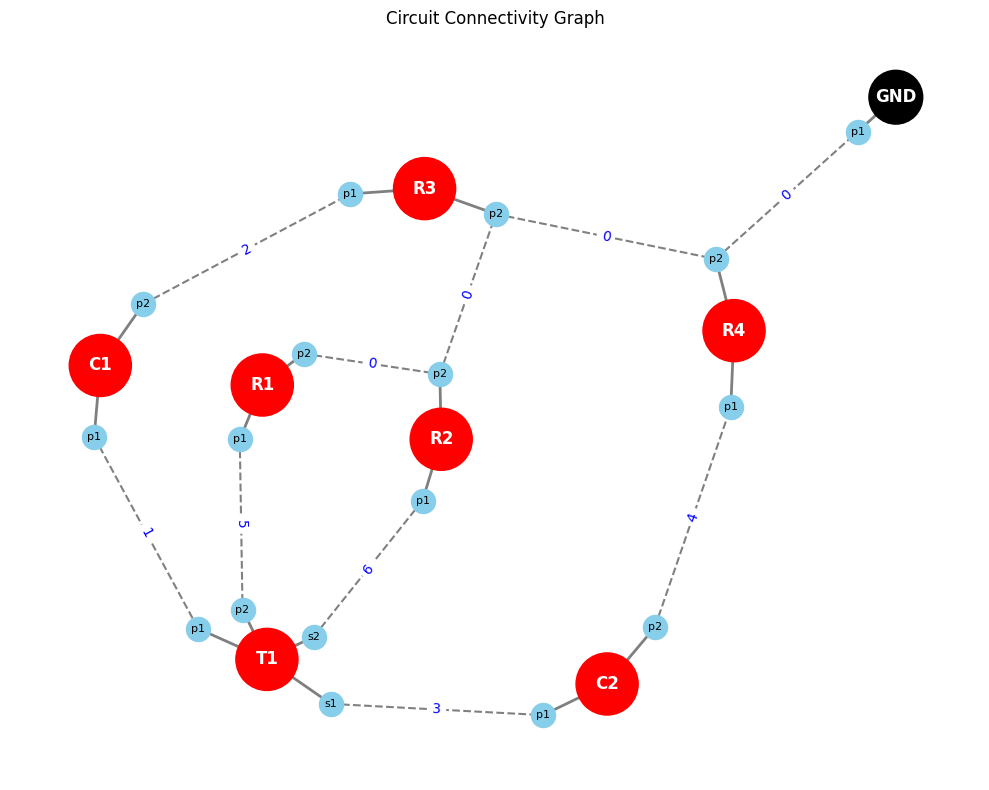

/tmp/ipykernel_84052/1434598961.py:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  graph.show()


In [31]:
from circulax.netlist import draw_circuit_graph

Rs = 5
L = 120e-12
C = 7e-15
Rp = 0.05 / (2 * jnp.pi * jnp.sqrt(L / C))
k = 0.9

sim_transf = {
    "instances": {
        # ground
        "GND": {"component": "ground"},
        # transformer
        "T1": {"component": "transformer", "settings": {"L1": L, "L2": L, "M": k * L}},
        # parallel capacitance
        "C1": {"component": "capacitor", "settings": {"C": C}},
        "C2": {"component": "capacitor", "settings": {"C": C}},
        # series resistance
        "R1": {"component": "resistor", "settings": {"R": Rs}},
        "R2": {"component": "resistor", "settings": {"R": Rs}},
        # dielectric losses
        "R3": {"component": "resistor", "settings": {"R": Rp}},
        "R4": {"component": "resistor", "settings": {"R": Rp}},
    },
    "connections": {
        # node 0
        "GND,p1": ("R1,p2", "R2,p2", "R3,p2", "R4,p2"),
        # primary side
        "R1,p1": "T1,p2",
        "R3,p1": "C1,p2",
        "C1,p1": "T1,p1",  # secondary
        "R2,p1": "T1,s2",
        "R4,p1": "C2,p2",
        "C2,p1": "T1,s1",
    },
}

# component definitions
models = {
    "resistor": Resistor,
    "capacitor": Capacitor,
    "transformer": Transformer,
    "ground": lambda: 0,
}

circuit = compile_circuit(sim_transf, models)
graph = draw_circuit_graph(netlist=sim_transf)
graph.set_size_inches(6, 6)
graph.show()

### S- and Z-parameters from the `circulax` model

With the lumped-element circuit compiled, we run the same kind of broadband AC sweep as we would on lab or EM data: evaluate the DC operating point, sweep frequency, and extract S-parameters at the two differential ports, then convert to Z-parameters. These are the **circuit-model** S/Z-parameters, to be compared against the Palace results computed earlier.

In [32]:
# evaluate dc point
y_dc = circuit()

# select port nodes
port_nodes = [circuit.port_map["T1,p1"], circuit.port_map["T1,s1"]]

# setup ac sweep
run_ac = setup_ac_sweep(circuit.groups, circuit.sys_size, port_nodes, z0=Z0)

# choose target frequencies
freqs = jnp.logspace(9, 12, 61)  # 1 GHz to 1 THz

# evaluate S parameters
S = run_ac(y_dc, freqs)

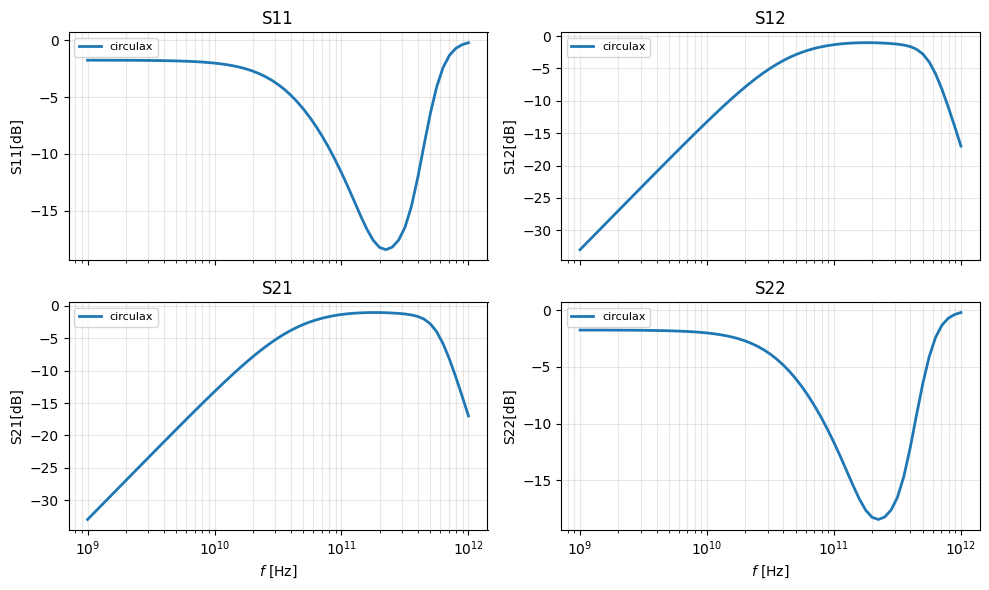

In [33]:
# plot S-parameters
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

params = [(0, 0, "S11"), (0, 1, "S12"), (1, 0, "S21"), (1, 1, "S22")]
for i, j, label in params:
    ax = axes[i][j]
    ax.semilogx(
        freqs, 20 * jnp.log10(jnp.abs(S[:, i, j])), "C0", lw=2, label="circulax"
    )
    ax.set_title(label)
    ax.set_ylabel(label + "[dB]")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("$f$ [Hz]")

plt.tight_layout()
plt.show()

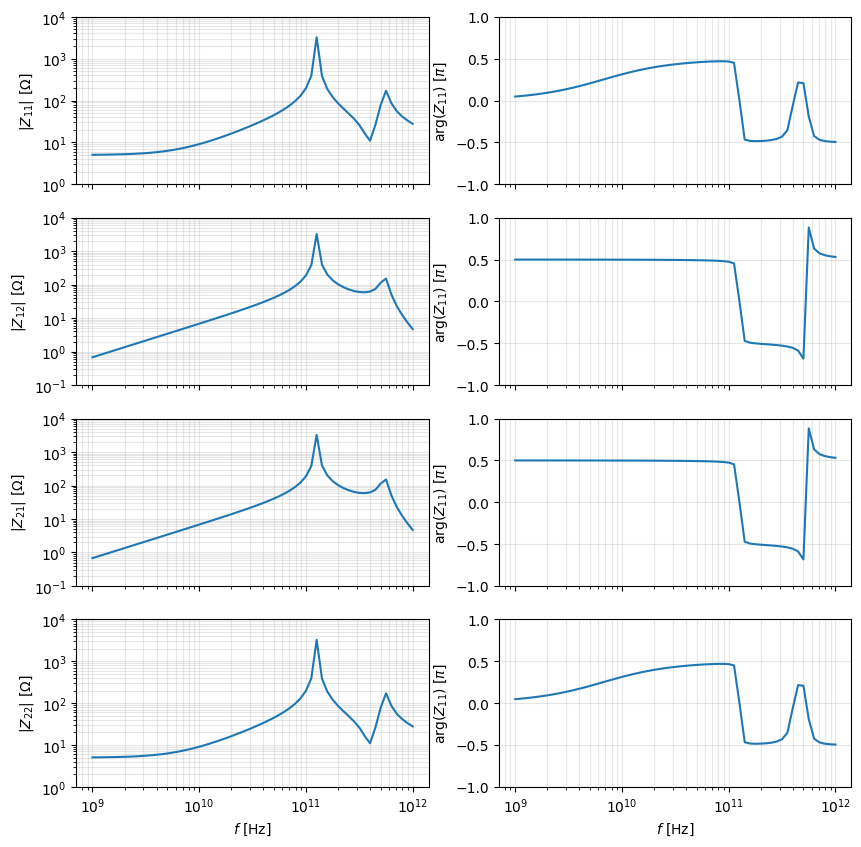

In [34]:
# calculate Z matrix
I = jnp.array([jnp.eye(2, 2)] * len(freqs))
Z = Z0 * jnp.linalg.solve(I - S, I + S)

fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True)

for i in range(4):
    j1 = int(jnp.floor(i / 2))
    j2 = int(i % 2)
    Zij = Z[:, j1, j2]

    ax = axes[i, 0]
    ax.loglog(freqs, jnp.abs(Zij), lw=1.5)
    ax.set_ylabel(r"$|Z_{" + f"{j1 + 1}{j2 + 1}" + r"}|$ [$\Omega$]")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(
        10 ** jnp.floor(jnp.log10(jnp.min(jnp.abs(Zij)))),
        10 ** jnp.ceil(jnp.log10(jnp.max(jnp.abs(Zij)))),
    )
    if i == 3:
        ax.set_xlabel("$f$ [Hz]")

    # phase
    ax = axes[i, 1]
    ax.semilogx(freqs, jnp.angle(Zij) / jnp.pi, lw=1.5)
    ax.set_ylabel(r"arg$(Z_{11})$ [$\pi$]")
    ax.grid(True, which="both", alpha=0.3)
    ax.set_ylim(-1, 1)
    if i == 3:
        ax.set_xlabel("$f$ [Hz]")

## Parameter Extraction and Fit

The `circulax` model above uses carried-over parameters and a guessed coupling coefficient — it hasn't actually been fit to this transformer's Palace simulation yet. Next, we'll reduce the Palace results to the differential-mode target impedances ($Z_{dd11}$, $Z_{dd22}$, $Z_{dd12}$), treat the netlist's `L1, L2, M, Rs, Rp, C` as free parameters, and use JAX/`optax` to minimize the error between the model's and the simulation's differential impedances across frequency — recovering the physical inductance, coupling, and parasitic values that best reproduce the EM simulation.